# Getting Partial Results with `split_fileset`

When processing large filesets, individual files or datasets can fail — a broken XRootD link, a network timeout, a corrupt file. By default, one failure aborts the whole run and you lose all partial progress.

This notebook shows two utilities from `coffea.dataset_tools` that let you work around this:

- **`split_fileset`** — divides a fileset into independently-processable chunks so a single failure only loses one chunk
- **`hash_fileset`** — produces a stable content-based hash for a chunk, enabling on-disk caching so successfully processed chunks are never re-run

These work alongside the `use_result_type=True` flag on `processor.Runner`, which changes the runner's return value from a plain accumulator to an `Ok(Accumulatable)`/`Err(Exception)` result object — letting you decide what to do with each failed chunk instead of catching exceptions.

In [1]:
import hist
import coffea.processor as processor
from coffea.nanoevents import schemas
from coffea.dataset_tools import split_fileset, hash_fileset
from coffea.util import load, save

## 1. Processor

No changes are needed to the processor itself, `split_fileset` works with any existing `ProcessorABC` subclass.

In [2]:
class Processor(processor.ProcessorABC):
    def __init__(self):
        dataset_axis = hist.axis.StrCategory(name="dataset", label="", categories=[], growth=True)
        MET_axis = hist.axis.Regular(name="MET", label="MET [GeV]", bins=50, start=0, stop=100)
        self.output = processor.dict_accumulator({
            'MET': hist.Hist(dataset_axis, MET_axis),
            'cutflow': processor.defaultdict_accumulator(int)
        })

    def process(self, events):
        dataset = events.metadata["dataset"]
        MET = events.MET.pt
        self.output['cutflow']['all events'] += len(MET)
        self.output['cutflow']['number of chunks'] += 1
        self.output['MET'].fill(dataset=dataset, MET=MET)
        return self.output

    def postprocess(self, accumulator):
        pass

## 2. Setting up the Runner with `use_result_type=True`

By default, `processor.Runner.__call__` returns the accumulator directly or raises on error.
Setting `use_result_type=True` changes this: the runner returns an `Ok(output)` on success or `Err(exception)` on failure, without raising.

`use_result_type` works as an extension of `skipbadfiles`: the `skipbadfiles` value picks which exception types are considered "expected" (broken file, missing tree, etc.), and `use_result_type=True` flips the handling of those exceptions from a silent skip + warning to an explicit `Err` return. Exceptions outside that set still propagate as real bugs.

`skipbadfiles` is therefore **required** when `use_result_type=True`. The most common values are:

- `skipbadfiles=True` — match `OSError` (the default file/network family). Good for most IO-failure cases.
- `skipbadfiles=(FileNotFoundError, uproot.exceptions.KeyInFileError)` — restrict to a specific set.

With `split_fileset` you process each chunk independently and decide per-chunk what to do based on result type:

```python
run_result = run(chunk, processor_instance=Processor())
if run_result.is_ok():
    output, metrics = run_result.unwrap()
else:
    print(f"Chunk failed: {run_result.exception}")
```

The `Result` API:
- `result.is_ok()` — `True` if the chunk processed successfully
- `result.unwrap()` — returns the value (`output` or `(output, metrics)` when `savemetrics=True`), or raises if `Err`
- `result.exception` — the exception, if `Err`
- `result.value` — when an executor with `recoverable=True` produced a partial accumulator before the failure, this holds the salvaged output (otherwise `None`)

In [3]:
executor = processor.FuturesExecutor()

run = processor.Runner(
    executor=executor,
    schema=schemas.NanoAODSchema,
    savemetrics=True,
    skipbadfiles=True,        # which exception types count as "expected"
    use_result_type=True,     # ... and turn those into Err instead of silent skip
)

## 3. Splitting a fileset into chunks

`split_fileset` divides a fileset into a list of smaller filesets (chunks). Each chunk can be processed independently, so a failure in one chunk does not affect the others.

> **Note:** These chunks are *fileset-level* splits — a grouping of files — not the row-level chunks that coffea's executor creates internally when processing a single file.

**Parameters:**

- `fileset` — accepts any of the schemas understood by `processor.Runner`:
  - `{dataset: {"files": {path: treename, ...}}}` (per-file treename — used in this notebook)
  - `{dataset: {"files": [path, ...], "treename": ...}}` (dataset-level treename)
  - `{dataset: [path, ...]}` (bare list — requires `treename=` below)
- `strategy` — `"by_dataset"`: one dataset per chunk; `None` (default): all datasets together in each chunk
- `percentage` — integer that divides 100 evenly (e.g. 20, 25, 50); each chunk gets this percentage of each dataset's files
- `datasets` — list, callable, or tuple to restrict which datasets are included
- `treename` — required when any dataset uses list-format files without its own `treename` field; the value is folded into each chunk so the chunks remain self-contained for caching

**Splitting modes:**

- `strategy="by_dataset"` → one chunk per dataset
- `percentage=20` → 5 mixed chunks, each containing 20% of *every* dataset
- `strategy="by_dataset", percentage=20` → `N_datasets × 5` chunks, each dataset split separately
- `datasets=["X"]` + any of the above → strategy applied only to the listed datasets

File paths are sorted before slicing into bins, so chunk composition is deterministic regardless of input dict insertion order — important for stable cache keys via `hash_fileset`.

In [4]:
import pprint

fileset = {
    'SingleMu_0': {
        "files": {
            # broken link (intentional — demonstrates error handling)
            "root://eeeeeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root": "Events",
            "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root": "Events",
            "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/AB10FBAB-92C0-C043-933D-117FCC5704BA.root": "Events",
            "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/C6E8BB7F-7F54-0C4C-9EDF-479C7DBB12E4.root": "Events",
            "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/CB90AA65-868A-F548-A291-3837A3113162.root": "Events",
        }
    },
    'SingleMu_1': {
        "files": {
            "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/18B53494-657F-5744-8131-58ABA4EE00ED.root": "Events",
            "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/2CCE1139-F301-C341-AE1E-4D27AF294018.root": "Events",
            "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/300C603C-F1DD-4A40-B4DD-F4E0B239A460.root": "Events",
            "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/39251543-EE21-9C4C-80D5-5D9178F55C71.root": "Events",
            "root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/3BD29D89-9C4A-E743-8616-C6806281BF12.root": "Events",
        }
    }
}

# strategy="by_dataset": one chunk per dataset -> 2 chunks
chunks_1 = split_fileset(fileset, strategy="by_dataset")
print(f"strategy='by_dataset': {len(chunks_1)} chunks")
pprint.pprint(chunks_1)

print()
# strategy="by_dataset", percentage=20: 5 chunks per dataset -> 10 chunks total
chunks_2 = split_fileset(fileset, strategy="by_dataset", percentage=20)
print(f"strategy='by_dataset', percentage=20: {len(chunks_2)} chunks")

print()
# percentage=20: 5 mixed chunks — each chunk contains 20% of SingleMu_0 + 20% of SingleMu_1
chunks_3 = split_fileset(fileset, percentage=20)
print(f"percentage=20 (mixed): {len(chunks_3)} chunks")

strategy='by_dataset': 2 chunks
[{'SingleMu_0': {'files': {'root://eeeeeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
                           'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
                           'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/AB10FBAB-92C0-C043-933D-117FCC5704BA.root': 'Events',
                           'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_p

## 4. Example 1: `strategy="by_dataset"`

The fileset has two datasets: `SingleMu_0` (which contains a broken link) and `SingleMu_1` (all valid files).
With `strategy="by_dataset"`, each dataset is its own chunk — so the failure in `SingleMu_0` leaves `SingleMu_1` unaffected.

Expected result: the run for `SingleMu_0` returns `Err`, the run for `SingleMu_1` returns `Ok` and its output is accumulated.

In [5]:
result = None

for chunk in chunks_1:
    run_result = run(chunk, processor_instance=Processor())
    if run_result.is_ok():
        output, metrics = run_result.unwrap()
    else:
        # user can implement their own logic on how to treat failed chunks
        print(f"Error processing chunk: {run_result.exception}")
        continue
    if result is None:
        result = output
    else:
        result += output

Output()

/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py:1277: UserWarning: Performed attempt 1 out of 4
  warnings.warn(
/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py:1277: UserWarning: Performed attempt 2 out of 4
  warnings.warn(
/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py:1277: UserWarning: Performed attempt 3 out of 4
  warnings.warn(
/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py:1277: UserWarning: Performed attempt 4 out of 4
  warnings.warn(


loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/home/iason/micromamba/envs/py3.14/lib/python3.14/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
  File "/home/iason/micromamba/envs/py3.14/lib/python3.14/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py", line 1289, in automatic_retries
    raise e
  File "/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py", line 1275, in automatic_retries
    return func(*args, **kwargs)
  File "/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py", line 1359, in metadata_fetcher_root
    with uproot.open(
         ~~~~~~~~~~~^
        {item.filename: None}, timeout=xrootdtimeout, **uproot_options
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Error processing chunk: XRootD error: [FATAL] Invalid address


Output()

Output()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f54b9ceb0e0>, errorbar=None, legend_artist=None)]

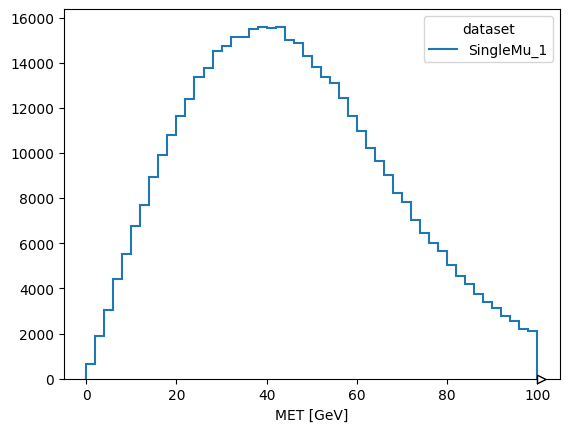

In [6]:
result['MET'].plot1d()

In [7]:
for key, value in result['cutflow'].items():
    print(key, value)

all events 482000
number of chunks 6


## 5. Example 2: `strategy="by_dataset", percentage=20`

Each dataset is split into 5 chunks of 20% each -> 10 chunks total (5 per dataset).
Only the one chunk from `SingleMu_0` that contains the broken file will fail; the other 4 chunks from `SingleMu_0` and all 5 from `SingleMu_1` succeed.

Expected result: 9 of 10 chunks succeed and are accumulated.

In [8]:
result_2 = None

for chunk in chunks_2:
    run_result = run(chunk, processor_instance=Processor())
    if run_result.is_ok():
        output, metrics = run_result.unwrap()
    else:
        # user can implement their own logic on how to treat failed chunks
        print(f"Error processing chunk: {run_result.exception}")
        continue
    if result_2 is None:
        result_2 = output
    else:
        result_2 += output

Output()

loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/home/iason/micromamba/envs/py3.14/lib/python3.14/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
  File "/home/iason/micromamba/envs/py3.14/lib/python3.14/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py", line 1289, in automatic_retries
    raise e
  File "/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py", line 1275, in automatic_retries
    return func(*args, **kwargs)
  File "/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py", line 1359, in metadata_fetcher_root
    with uproot.open(
         ~~~~~~~~~~~^
        {item.filename: None}, timeout=xrootdtimeout, **uproot_options
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Error processing chunk: XRootD error: [FATAL] Invalid address


Output()

Output()

...

Output()

Output()

Output()

Output()

Output()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f54b9adc550>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f54b9adc690>, errorbar=None, legend_artist=None)]

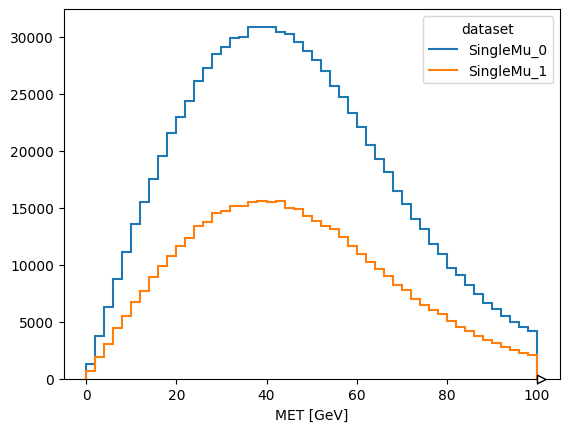

In [9]:
result_2['MET'].plot1d()

In [10]:
for key, value in result_2['cutflow'].items():
    print(key, value)

all events 1439000
number of chunks 17


## 6. Stable chunk identity for caching

`hash_fileset` returns a stable SHA-256 hex string for a chunk. The hash covers dataset names, sorted file paths, and all output-affecting dataset-level fields (`treename`, `preload`, `metadata`) in canonical form, so chunks that differ in any of those will hash differently. The hash is consistent across sessions, making it suitable as a cache key.

```python
chunk_hash = hash_fileset(chunk)
# gives 'a3f2c1...'
```

> **Note:** `hash_fileset` requires self-contained chunks. A bare `{dataset: [path, ...]}` (or `{dataset: {"files": [path, ...]}}` without a `treename` field) is rejected — pass `treename=` to `split_fileset` first so the chunks carry their own tree name.

The typical pattern: before running a chunk, check if a cached result already exists on disk. If it does, load it. If not, run the processor, save the result, and use it. On a subsequent run (or after a partial failure), already-processed chunks are loaded from cache and only missing chunks are recomputed.

## 7. Example 3: on-disk caching + (`percentage=20`, mixed chunks)

With `percentage=20` and no strategy, each chunk is a *mix* of 20% of every dataset — so `SingleMu_0` and `SingleMu_1` appear together in each chunk.
The chunk that contains the broken `SingleMu_0` file will fail, but the remaining 4 mixed chunks succeed.

Successfully processed chunks are saved to `./chunk_cache/`. Re-running this cell will load them from disk and skip reprocessing.

In [11]:
import os

result_3 = None
cache_dir = "./chunk_cache"
os.makedirs(cache_dir, exist_ok=True)

In [12]:
for chunk in chunks_3:
    chunk_hash = hash_fileset(chunk)
    cache_path = os.path.join(cache_dir, f"{chunk_hash}.coffea")

    if os.path.exists(cache_path):
        print(f"Loading cached result for chunk {chunk_hash[:8]}...")
        output = load(cache_path)
    else:
        run_result = run(chunk, processor_instance=Processor())
        if run_result.is_ok():
            output, metrics = run_result.unwrap()
            save(output, cache_path)
            print(f"Saved result for chunk {chunk_hash[:8]}...")
        else:
            print(f"Error processing chunk {chunk_hash[:8]}...: {run_result.exception}")
            continue
    if result_3 is None:
        result_3 = output 
    else:
        result_3 += output

Output()

loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/home/iason/micromamba/envs/py3.14/lib/python3.14/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
  File "/home/iason/micromamba/envs/py3.14/lib/python3.14/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py", line 1289, in automatic_retries
    raise e
  File "/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py", line 1275, in automatic_retries
    return func(*args, **kwargs)
  File "/home/iason/Dropbox/work/pyhep_dev/coffea/src/coffea/processor/executor.py", line 1359, in metadata_fetcher_root
    with uproot.open(
         ~~~~~~~~~~~^
        {item.filename: None}, timeout=xrootdtimeout, **uproot_options
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Error processing chunk 5febc050...: XRootD error: [FATAL] Invalid address


Output()

Saved result for chunk 326dec70...


...

Saved result for chunk 28afadc5...


Output()

Saved result for chunk 7aab00fd...


Output()

Saved result for chunk bc4cbe30...


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f54b9b90550>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f54b9b90690>, errorbar=None, legend_artist=None)]

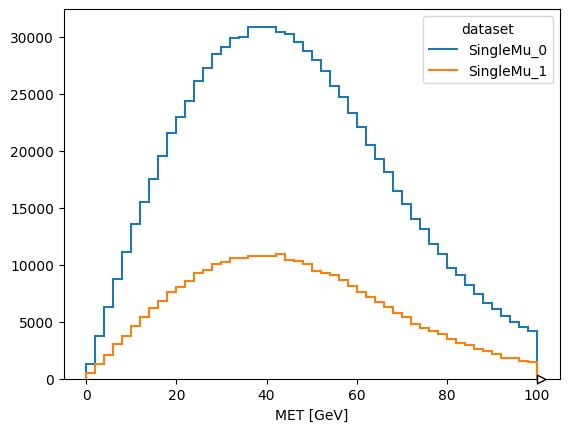

In [13]:
result_3['MET'].plot1d()

In [14]:
for key, value in result_3['cutflow'].items():
    print(key, value)

all events 1292000
number of chunks 16
